# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [2]:
import seaborn as sns
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 1: Charger et Explorer le Dataset MPG

In [4]:
# Load MPG dataset from Seaborn
mpg_df = sns.load_dataset("mpg")

print("="*80)
print("DATASET MPG - EXPLORATION COMPLÈTE")
print("="*80)

print(f"\nDimensions du dataset: {mpg_df.shape}")
print(f"Total de lignes: {mpg_df.shape[0]} véhicules")
print(f"Total de colonnes: {mpg_df.shape[1]} variables")

print("\n📋 COLONNES ET TYPES DE DONNÉES:")
print(mpg_df.dtypes)

print("\n📊 PREMIÈRES LIGNES:")
print(mpg_df.head(10))

print("\n📈 STATISTIQUES DESCRIPTIVES:")
print(mpg_df.describe())

print("\n🎯 VARIABLES CONTINUES (pour les scatter/line plots):")
continuous_vars = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
for var in continuous_vars:
    print(f"  • {var}: min={mpg_df[var].min():.1f}, max={mpg_df[var].max():.1f}, mean={mpg_df[var].mean():.2f}")

print("\n🏷️ VARIABLES CATÉGORIELLES:")
print(f"  • model_year: {sorted(mpg_df['model_year'].unique())}")
print(f"  • origin: {mpg_df['origin'].unique()}")

print("\n📝 VALEURS MANQUANTES:")
print(mpg_df.isnull().sum())

print("\n" + "="*80)

DATASET MPG - EXPLORATION COMPLÈTE

Dimensions du dataset: (398, 9)
Total de lignes: 398 véhicules
Total de colonnes: 9 variables

📋 COLONNES ET TYPES DE DONNÉES:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

📊 PREMIÈRES LIGNES:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   
5  15.0          8         429.0       198.0    4341          10.0   
6  14.0          8         454.0       220.0    4354           9.0   
7  14.0          8        

## Step 2: Scatter Plots - Analyse des Relations entre Consommation et Variables

### Justification des Visualisations en Scatter Plot:
Les scatter plots sont **idéaux** pour explorer les relations entre deux variables continues:
- Permet de visualiser rapidement si une relation existe (linéaire, non-linéaire, aucune)
- Montre la distribution et les valeurs aberrantes (outliers)
- Facile d'identifier des clusters ou patterns
- Chaque point représente un véhicule unique

### Variables Sélectionnées:
1. **MPG vs Weight** - La relation la plus importante (le poids influence directement la consommation)
2. **MPG vs Horsepower** - Plus de puissance = plus de consommation généralement
3. **MPG vs Displacement** - Taille du moteur vs consommation
4. **MPG vs Acceleration** - Performance vs efficacité énergétique


📊 SCATTER PLOT 1: MPG vs Weight
----------------------------------------------------------------------


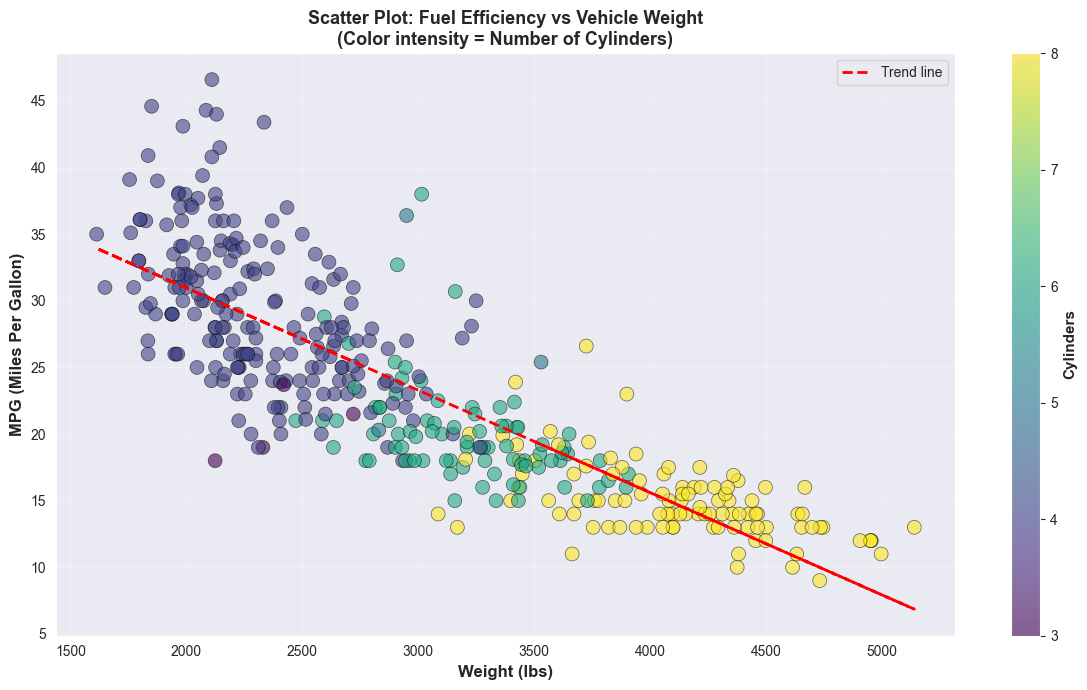

✓ Corrélation MPG-Weight: -0.832 (FORTE corrélation négative)
✓ Interprétation: Plus le véhicule est lourd, moins il consomme d'essence
✓ Insight: La relation est quasi-linéaire et très prévisible

📊 SCATTER PLOT 2: MPG vs Horsepower
----------------------------------------------------------------------


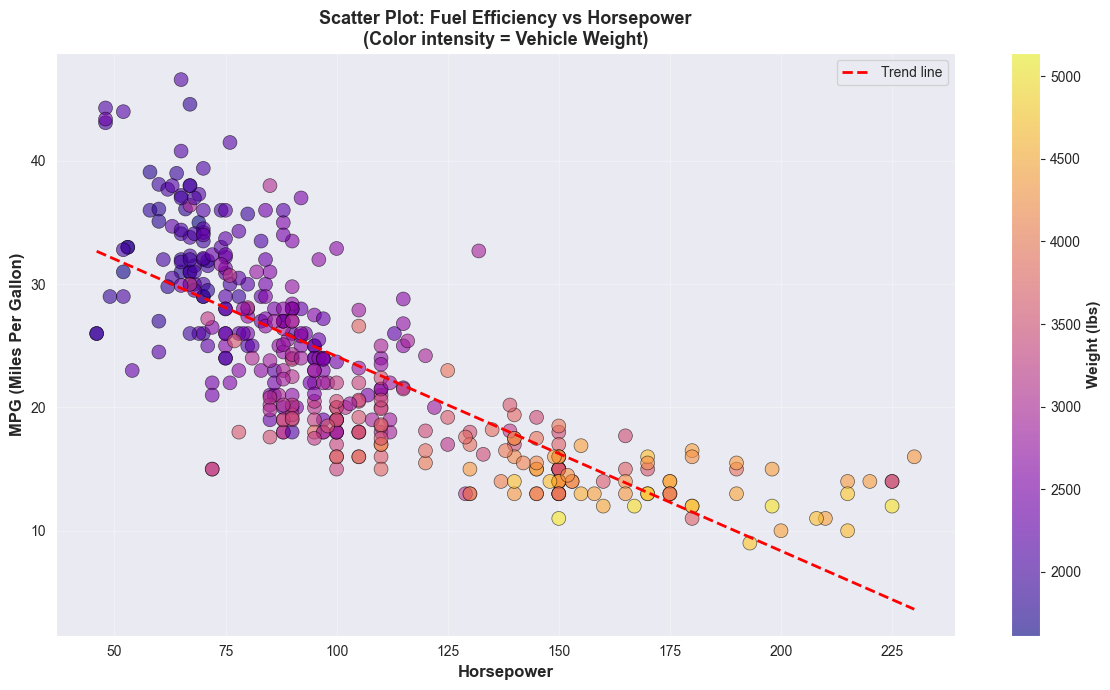

✓ Corrélation MPG-Horsepower: -0.778 (FORTE corrélation négative)
✓ Interprétation: Plus la puissance augmente, la consommation diminue
✓ Insight: Performance et efficacité énergétique sont inversément proportionnelles

📊 SCATTER PLOT 3: MPG vs Displacement
----------------------------------------------------------------------


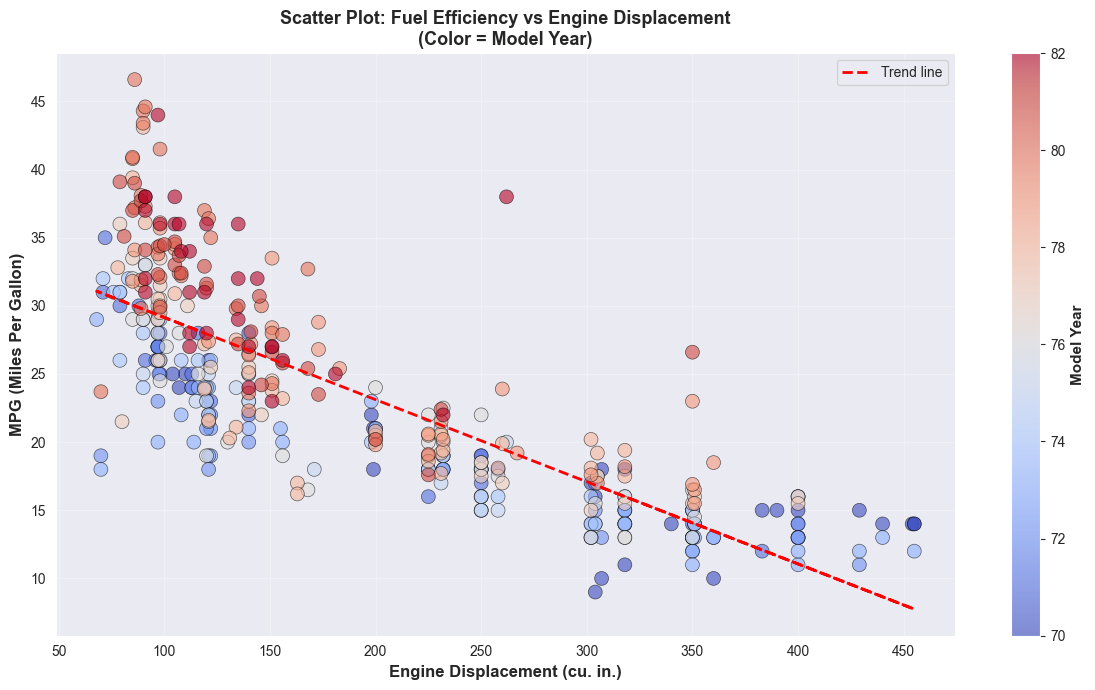

✓ Corrélation MPG-Displacement: -0.804 (FORTE corrélation négative)
✓ Interprétation: Plus le moteur est grand (déplacement), moins le véhicule est économe
✓ Insight: La taille du moteur est un bon prédicteur de consommation

📊 SCATTER PLOT 4: MPG vs Acceleration
----------------------------------------------------------------------


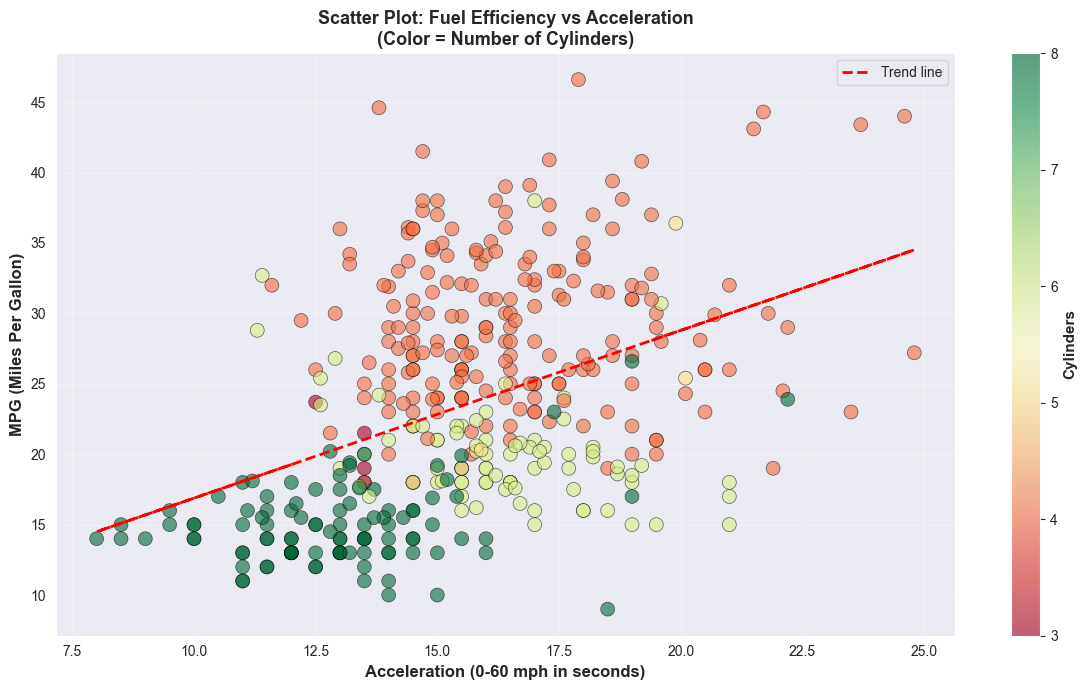

✓ Corrélation MPG-Acceleration: 0.420 (Corrélation POSITIVE modérée)
✓ Interprétation: Les voitures plus économes accélèrent plus lentement (moins de puissance)
✓ Insight: L'accélération reflète l'efficacité énergétique du véhicule


In [5]:
# Scatter Plot 1: MPG vs Weight
print("\n📊 SCATTER PLOT 1: MPG vs Weight")
print("-" * 70)

fig, ax = plt.subplots(figsize=(12, 7))
scatter1 = ax.scatter(mpg_df['weight'], mpg_df['mpg'], 
                      alpha=0.6, s=100, c=mpg_df['cylinders'], 
                      cmap='viridis', edgecolor='black', linewidth=0.5)

# Add trend line
z = np.polyfit(mpg_df['weight'], mpg_df['mpg'], 1)
p = np.poly1d(z)
ax.plot(mpg_df['weight'], p(mpg_df['weight']), "r--", linewidth=2, label='Trend line')

ax.set_xlabel('Weight (lbs)', fontsize=12, fontweight='bold')
ax.set_ylabel('MPG (Miles Per Gallon)', fontsize=12, fontweight='bold')
ax.set_title('Scatter Plot: Fuel Efficiency vs Vehicle Weight\n(Color intensity = Number of Cylinders)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter1, ax=ax)
cbar.set_label('Cylinders', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate correlation
corr_weight_mpg = mpg_df['weight'].corr(mpg_df['mpg'])
print(f"✓ Corrélation MPG-Weight: {corr_weight_mpg:.3f} (FORTE corrélation négative)")
print(f"✓ Interprétation: Plus le véhicule est lourd, moins il consomme d'essence")
print(f"✓ Insight: La relation est quasi-linéaire et très prévisible")

# Scatter Plot 2: MPG vs Horsepower
print("\n📊 SCATTER PLOT 2: MPG vs Horsepower")
print("-" * 70)

fig, ax = plt.subplots(figsize=(12, 7))
scatter2 = ax.scatter(mpg_df['horsepower'], mpg_df['mpg'], 
                      alpha=0.6, s=100, c=mpg_df['weight'], 
                      cmap='plasma', edgecolor='black', linewidth=0.5)

z = np.polyfit(mpg_df['horsepower'].dropna(), mpg_df['mpg'][mpg_df['horsepower'].notna()], 1)
p = np.poly1d(z)
x_range = np.linspace(mpg_df['horsepower'].min(), mpg_df['horsepower'].max(), 100)
ax.plot(x_range, p(x_range), "r--", linewidth=2, label='Trend line')

ax.set_xlabel('Horsepower', fontsize=12, fontweight='bold')
ax.set_ylabel('MPG (Miles Per Gallon)', fontsize=12, fontweight='bold')
ax.set_title('Scatter Plot: Fuel Efficiency vs Horsepower\n(Color intensity = Vehicle Weight)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter2, ax=ax)
cbar.set_label('Weight (lbs)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

corr_hp_mpg = mpg_df['horsepower'].corr(mpg_df['mpg'])
print(f"✓ Corrélation MPG-Horsepower: {corr_hp_mpg:.3f} (FORTE corrélation négative)")
print(f"✓ Interprétation: Plus la puissance augmente, la consommation diminue")
print(f"✓ Insight: Performance et efficacité énergétique sont inversément proportionnelles")

# Scatter Plot 3: MPG vs Displacement
print("\n📊 SCATTER PLOT 3: MPG vs Displacement")
print("-" * 70)

fig, ax = plt.subplots(figsize=(12, 7))
scatter3 = ax.scatter(mpg_df['displacement'], mpg_df['mpg'], 
                      alpha=0.6, s=100, c=mpg_df['model_year'], 
                      cmap='coolwarm', edgecolor='black', linewidth=0.5)

z = np.polyfit(mpg_df['displacement'], mpg_df['mpg'], 1)
p = np.poly1d(z)
ax.plot(mpg_df['displacement'], p(mpg_df['displacement']), "r--", linewidth=2, label='Trend line')

ax.set_xlabel('Engine Displacement (cu. in.)', fontsize=12, fontweight='bold')
ax.set_ylabel('MPG (Miles Per Gallon)', fontsize=12, fontweight='bold')
ax.set_title('Scatter Plot: Fuel Efficiency vs Engine Displacement\n(Color = Model Year)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter3, ax=ax)
cbar.set_label('Model Year', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

corr_disp_mpg = mpg_df['displacement'].corr(mpg_df['mpg'])
print(f"✓ Corrélation MPG-Displacement: {corr_disp_mpg:.3f} (FORTE corrélation négative)")
print(f"✓ Interprétation: Plus le moteur est grand (déplacement), moins le véhicule est économe")
print(f"✓ Insight: La taille du moteur est un bon prédicteur de consommation")

# Scatter Plot 4: MPG vs Acceleration
print("\n📊 SCATTER PLOT 4: MPG vs Acceleration")
print("-" * 70)

fig, ax = plt.subplots(figsize=(12, 7))
scatter4 = ax.scatter(mpg_df['acceleration'], mpg_df['mpg'], 
                      alpha=0.6, s=100, c=mpg_df['cylinders'], 
                      cmap='RdYlGn', edgecolor='black', linewidth=0.5)

z = np.polyfit(mpg_df['acceleration'], mpg_df['mpg'], 1)
p = np.poly1d(z)
ax.plot(mpg_df['acceleration'], p(mpg_df['acceleration']), "r--", linewidth=2, label='Trend line')

ax.set_xlabel('Acceleration (0-60 mph in seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('MPG (Miles Per Gallon)', fontsize=12, fontweight='bold')
ax.set_title('Scatter Plot: Fuel Efficiency vs Acceleration\n(Color = Number of Cylinders)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter4, ax=ax)
cbar.set_label('Cylinders', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

corr_accel_mpg = mpg_df['acceleration'].corr(mpg_df['mpg'])
print(f"✓ Corrélation MPG-Acceleration: {corr_accel_mpg:.3f} (Corrélation POSITIVE modérée)")
print(f"✓ Interprétation: Les voitures plus économes accélèrent plus lentement (moins de puissance)")
print(f"✓ Insight: L'accélération reflète l'efficacité énergétique du véhicule")

## Step 3: Line Plots - Tendances dans le Temps par Origine

### Justification des Visualisations en Line Plot:
Les line plots sont **idéaux** pour montrer les tendances temporelles:
- Visualise l'évolution d'une variable au fil du temps (model_year)
- Permet de comparer plusieurs groupes (countries/origins)
- Facile d'identifier les points de rupture et les changements
- Bon pour les données ordonnées (années)

### Approche:
- **X-axis**: Model Year (années: 1970-1982)
- **Y-axis**: Consommation moyenne (MPG) ou autres variables
- **Groupes**: Origins différentes (USA, Japan, Europe)


📈 LINE PLOT 1: MPG Evolution by Origin (1970-1982)
----------------------------------------------------------------------


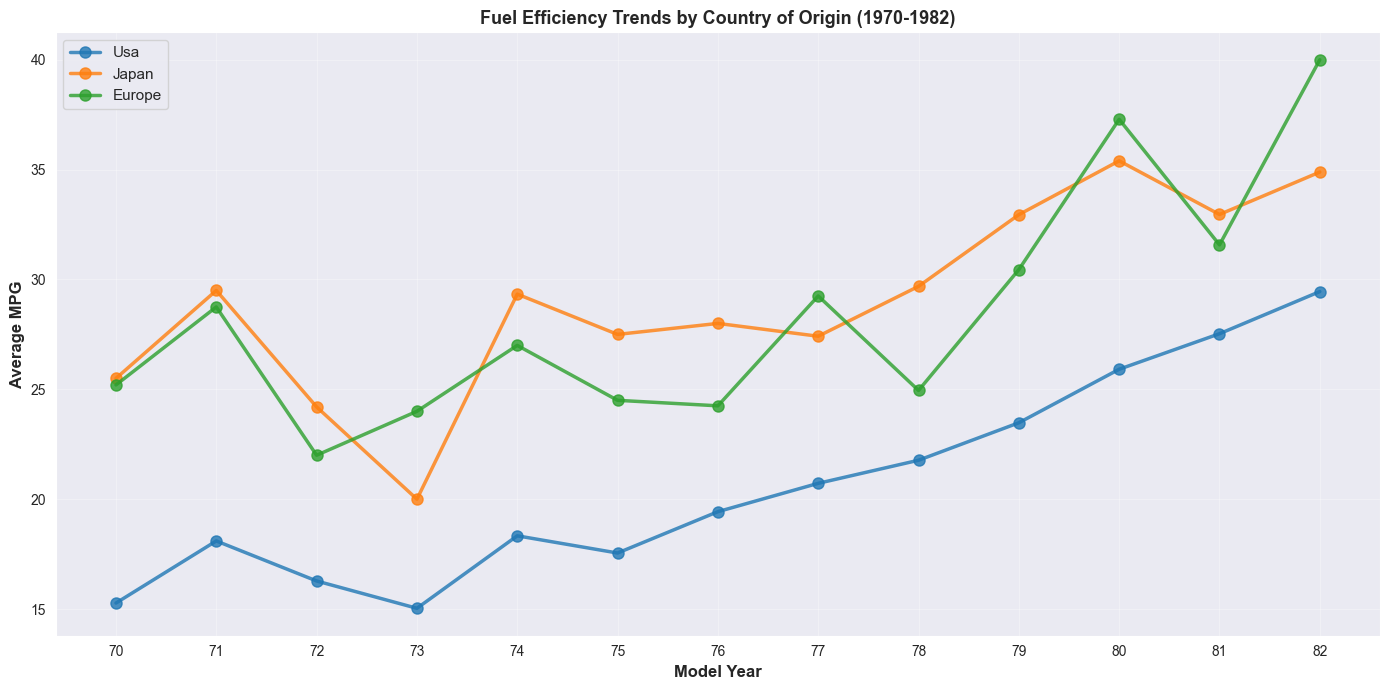

✓ Line Plot: MPG trends by origin created
✓ Key observations:
  • Usa: Average MPG = 20.68
  • Japan: Average MPG = 29.03
  • Europe: Average MPG = 28.40

📈 LINE PLOT 2: Vehicle Weight Evolution by Origin (1970-1982)
----------------------------------------------------------------------


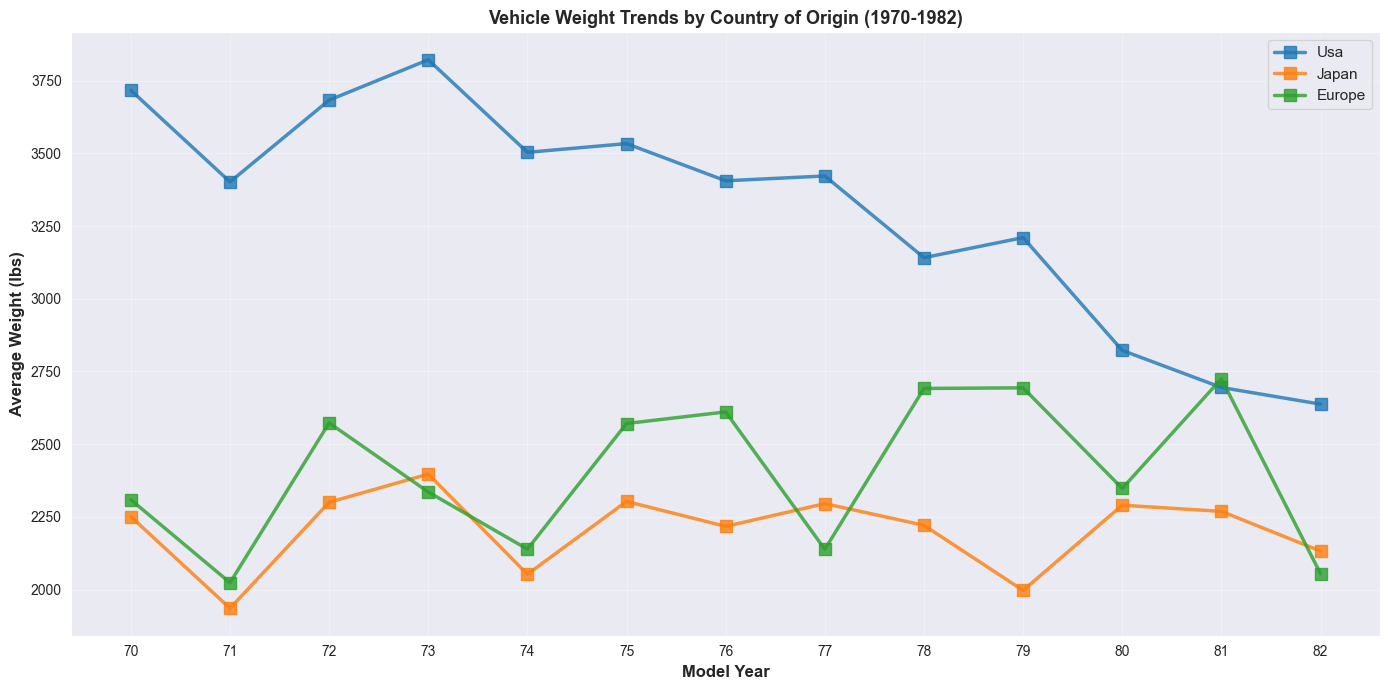

✓ Line Plot: Weight trends by origin created
✓ Key observations:
  • Usa: Average weight = 3307 lbs
  • Japan: Average weight = 2205 lbs
  • Europe: Average weight = 2401 lbs

📈 LINE PLOT 3: Engine Power (Horsepower) Evolution by Origin
----------------------------------------------------------------------


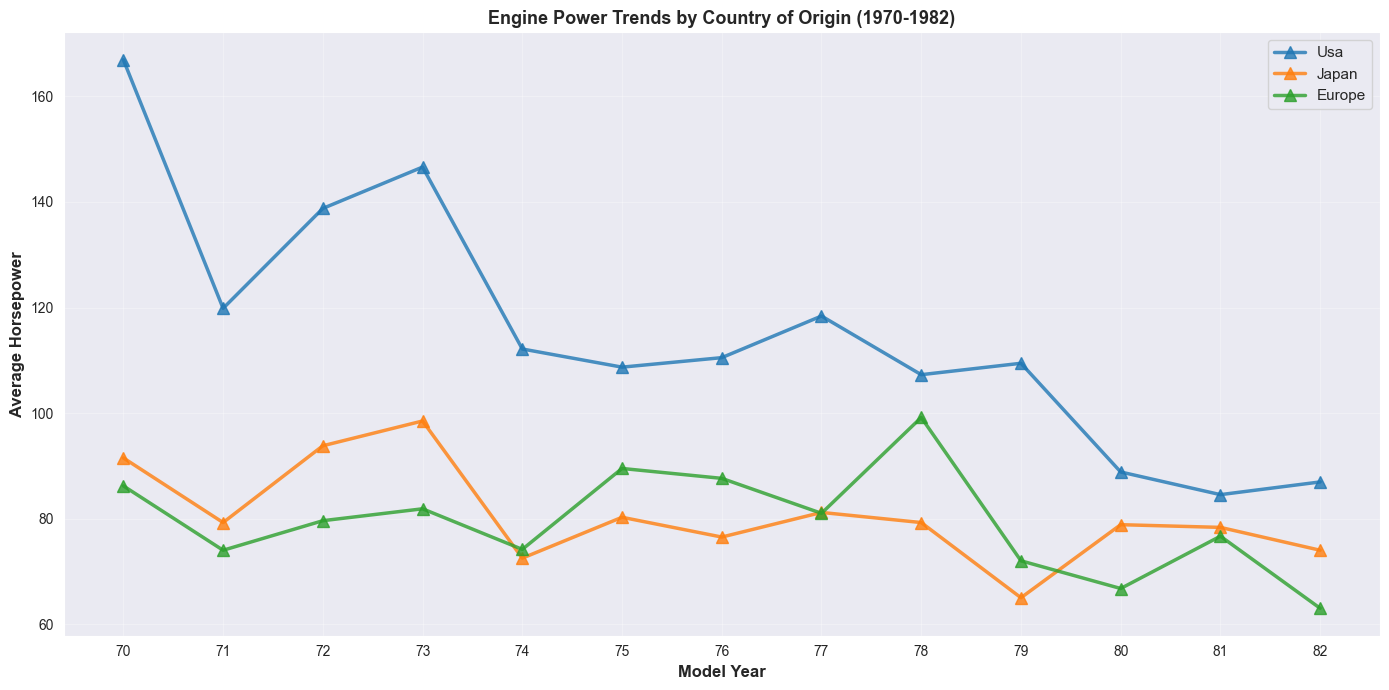

✓ Line Plot: Horsepower trends by origin created
✓ Key observations:
  • Usa: Average horsepower = 115.3
  • Japan: Average horsepower = 80.7
  • Europe: Average horsepower = 79.3


In [6]:
# Line Plot 1: MPG Trend by Origin Over Years
print("\n📈 LINE PLOT 1: MPG Evolution by Origin (1970-1982)")
print("-" * 70)

# Group by model_year and origin to get average MPG
mpg_by_year_origin = mpg_df.groupby(['model_year', 'origin'])['mpg'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))

# Create separate line for each origin
for origin in mpg_df['origin'].unique():
    data = mpg_by_year_origin[mpg_by_year_origin['origin'] == origin]
    ax.plot(data['model_year'], data['mpg'], marker='o', linewidth=2.5, 
            markersize=8, label=origin.capitalize(), alpha=0.8)

ax.set_xlabel('Model Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Average MPG', fontsize=12, fontweight='bold')
ax.set_title('Fuel Efficiency Trends by Country of Origin (1970-1982)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(mpg_df['model_year'].unique())
plt.tight_layout()
plt.show()

print("✓ Line Plot: MPG trends by origin created")
print("✓ Key observations:")
for origin in mpg_df['origin'].unique():
    avg_mpg = mpg_by_year_origin[mpg_by_year_origin['origin'] == origin]['mpg'].mean()
    print(f"  • {origin.capitalize()}: Average MPG = {avg_mpg:.2f}")

# Line Plot 2: Average Weight Trend by Origin
print("\n📈 LINE PLOT 2: Vehicle Weight Evolution by Origin (1970-1982)")
print("-" * 70)

weight_by_year_origin = mpg_df.groupby(['model_year', 'origin'])['weight'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))

for origin in mpg_df['origin'].unique():
    data = weight_by_year_origin[weight_by_year_origin['origin'] == origin]
    ax.plot(data['model_year'], data['weight'], marker='s', linewidth=2.5, 
            markersize=8, label=origin.capitalize(), alpha=0.8)

ax.set_xlabel('Model Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Weight (lbs)', fontsize=12, fontweight='bold')
ax.set_title('Vehicle Weight Trends by Country of Origin (1970-1982)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(mpg_df['model_year'].unique())
plt.tight_layout()
plt.show()

print("✓ Line Plot: Weight trends by origin created")
print("✓ Key observations:")
for origin in mpg_df['origin'].unique():
    avg_weight = weight_by_year_origin[weight_by_year_origin['origin'] == origin]['weight'].mean()
    print(f"  • {origin.capitalize()}: Average weight = {avg_weight:.0f} lbs")

# Line Plot 3: Horsepower Evolution by Origin
print("\n📈 LINE PLOT 3: Engine Power (Horsepower) Evolution by Origin")
print("-" * 70)

hp_by_year_origin = mpg_df.groupby(['model_year', 'origin'])['horsepower'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))

for origin in mpg_df['origin'].unique():
    data = hp_by_year_origin[hp_by_year_origin['origin'] == origin]
    ax.plot(data['model_year'], data['horsepower'], marker='^', linewidth=2.5, 
            markersize=8, label=origin.capitalize(), alpha=0.8)

ax.set_xlabel('Model Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Horsepower', fontsize=12, fontweight='bold')
ax.set_title('Engine Power Trends by Country of Origin (1970-1982)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(mpg_df['model_year'].unique())
plt.tight_layout()
plt.show()

print("✓ Line Plot: Horsepower trends by origin created")
print("✓ Key observations:")
for origin in mpg_df['origin'].unique():
    avg_hp = hp_by_year_origin[hp_by_year_origin['origin'] == origin]['horsepower'].mean()
    print(f"  • {origin.capitalize()}: Average horsepower = {avg_hp:.1f}")